# 6CS012 Final Portfolio Project 2026
## Part III – Language Tasks: Sentiment Analysis of Financial Phrases using RNN, LSTM, and Word2Vec

**Dataset:** Financial PhraseBank  
**Classes:** `positive`, `negative`, `neutral`  
**Models Built:** Simple RNN · LSTM (trainable embeddings) · LSTM (pretrained GloVe/Word2Vec)  

---

## 1. Install & Import Dependencies

In [1]:
# Install required packages (run once in Colab)
!pip install gensim --quiet
!pip install wordcloud --quiet

In [2]:
# ── Standard & Data Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import contractions
import warnings
warnings.filterwarnings('ignore')

# ── NLP ────────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)

# ── Keras / TensorFlow ─────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Gensim ─────────────────────────────────────────────────────────────────
import gensim.downloader as api

# ── Google Drive ───────────────────────────────────────────────────────────
from google.colab import drive

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print('All libraries loaded successfully ✓')

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries loaded successfully ✓


## 2. Load Dataset from Google Drive

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/AI/FinalCoursework/3. Description Financial Phrase Dataset.txt'

# Load dataset — CSV format: text, label
df = pd.read_csv(DATASET_PATH, header=0, names=['text', 'label'],
                 encoding='latin-1', on_bad_lines='skip')

# Drop any NaN rows
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape : {df.shape}')
print(f'\nLabel distribution :\n{df["label"].value_counts()}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape : (2264, 2)

Label distribution :
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


## 3. Exploratory Data Analysis (EDA)

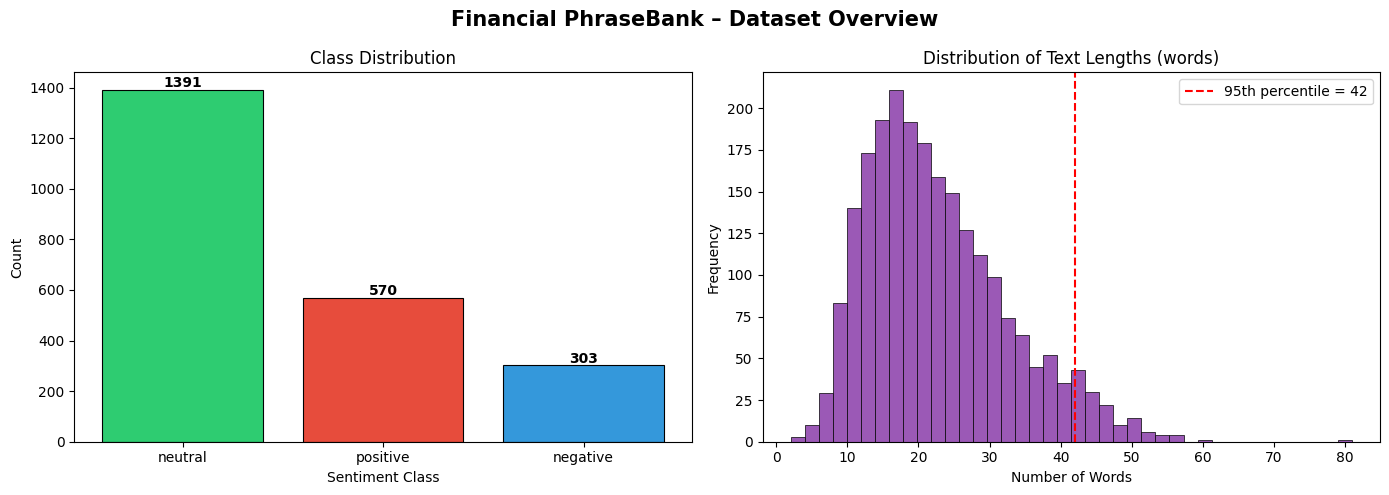


Text Length Stats:
count    2264.00
mean       22.45
std        10.15
min         2.00
25%        15.00
50%        21.00
75%        28.00
max        81.00
Name: text_length, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Financial PhraseBank – Dataset Overview', fontsize=15, fontweight='bold')

# ── Class Distribution Bar Chart ───────────────────────────────────────────
colors = ['#2ecc71', '#e74c3c', '#3498db']
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# ── Text Length Distribution ───────────────────────────────────────────────
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
axes[1].hist(df['text_length'], bins=40, color='#9b59b6', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribution of Text Lengths (words)')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_length'].quantile(0.95), color='red', linestyle='--',
                label=f"95th percentile = {int(df['text_length'].quantile(0.95))}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nText Length Stats:\n{df['text_length'].describe().round(2)}")

## 4. Text Preprocessing

In [5]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions  (e.g. "don't" → "do not")
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 6. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 8. Remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOP_WORDS]
    # 9. Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

# Preview
print('Preprocessing complete ✓')
print('\nBefore:', df['text'].iloc[0])
print('After :', df['cleaned_text'].iloc[0])

Preprocessing complete ✓

Before: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
After : according gran company plan move production russia although company growing


## 5. Data Visualisation – Word Clouds & Frequency

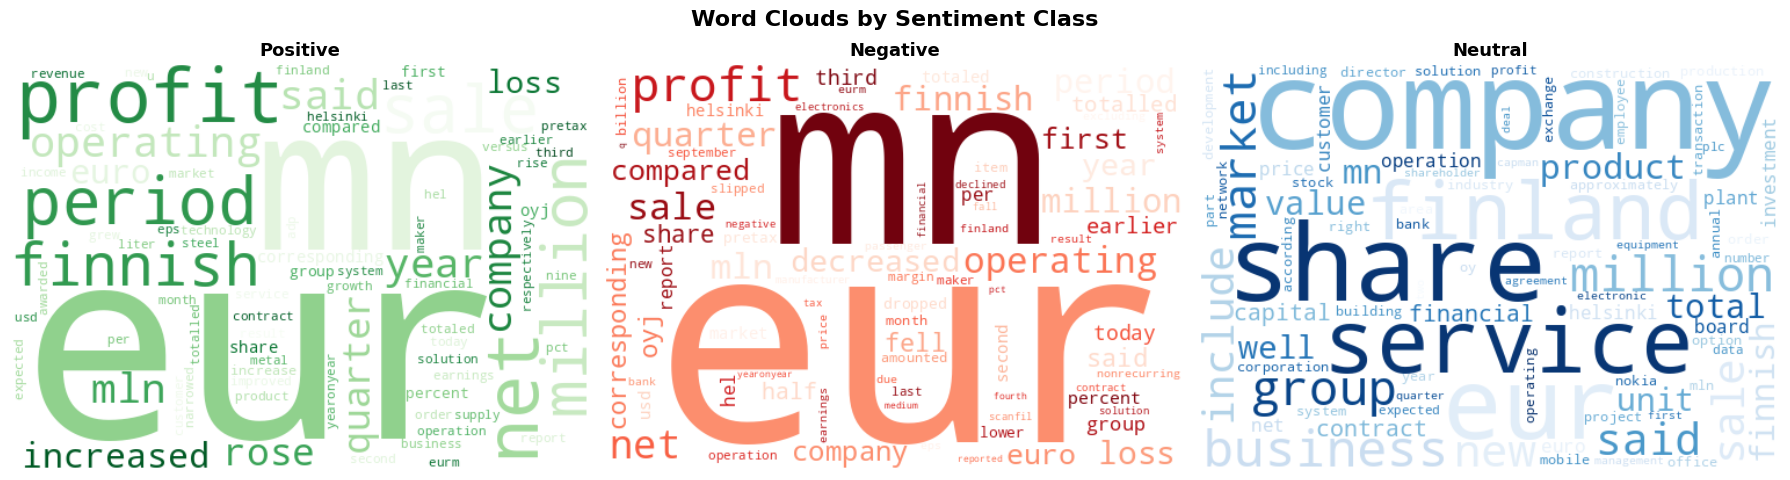

In [6]:
sentiments  = ['positive', 'negative', 'neutral']
cloud_colors = ['Greens', 'Reds', 'Blues']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')

for ax, sentiment, cmap in zip(axes, sentiments, cloud_colors):
    corpus = ' '.join(df[df['label'] == sentiment]['cleaned_text'])
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment.capitalize(), fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

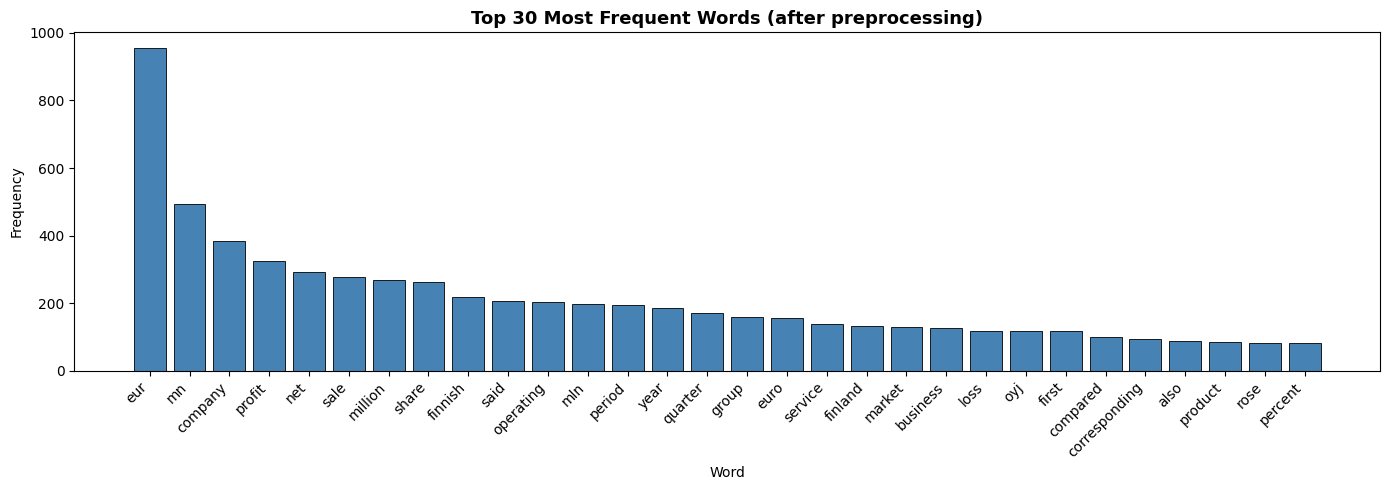

In [7]:
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
top_30 = Counter(all_words).most_common(30)
words, freqs = zip(*top_30)

plt.figure(figsize=(14, 5))
plt.bar(words, freqs, color='steelblue', edgecolor='black', linewidth=0.6)
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Frequent Words (after preprocessing)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tokenisation, Encoding & Padding

In [8]:
# ── Label Encoding ──────────────────────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f'Classes : {le.classes_}  →  {list(range(NUM_CLASSES))}')

# ── Train / Test Split (80/20) ──────────────────────────────────────────────
X = df['cleaned_text'].values
y = to_categorical(df['label_enc'].values, num_classes=NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=df['label_enc']
)
print(f'Train size : {len(X_train)} | Test size : {len(X_test)}')

# ── Keras Tokenizer ─────────────────────────────────────────────────────────
MAX_VOCAB = 10_000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Vocabulary size : {VOCAB_SIZE}')

# ── Sequences ───────────────────────────────────────────────────────────────
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based Padding (95th percentile of training lengths) ──────────
train_lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(train_lengths, 95))
print(f'Padding length (95th percentile) : {MAX_LEN}')

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad  shape : {X_test_pad.shape}')

Classes : ['negative' 'neutral' 'positive']  →  [0, 1, 2]
Train size : 1811 | Test size : 453
Vocabulary size : 4408
Padding length (95th percentile) : 22
X_train_pad shape : (1811, 22)
X_test_pad  shape : (453, 22)


## 7. Model 1 – Simple RNN with Trainable Embedding

In [9]:
EMBED_DIM = 64

def build_rnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, name='embedding'),
        SimpleRNN(64, return_sequences=False, name='rnn_layer'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax', name='output')
    ], name='Simple_RNN')
    return model

model1 = build_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)

model1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_layer (SimpleRNN)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6192 - loss: 0.8740 - val_accuracy: 0.7243 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7622 - loss: 0.5560 - val_accuracy: 0.7647 - val_loss: 0.5641 - learning_rate: 0.0010
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8337 - loss: 0.3718 - val_accuracy: 0.7463 - val_loss: 0.6370 - learning_rate: 0.0010
Epoch 4/20
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8789 - loss: 0.2837
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8941 - loss: 0.2662 - val_accuracy: 0.7500 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9487 - loss: 0.1573 - val_accuracy: 0.7610 - val_loss: 0.7008 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## 8. Model 2 – LSTM with Trainable Embedding

In [11]:
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, name='embedding'),
        LSTM(64, return_sequences=True, name='lstm_1'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, name='lstm_2'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='LSTM_Trainable')
    return model

model2 = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)

model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6342 - loss: 0.8990 - val_accuracy: 0.7574 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 2/20
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7772 - loss: 0.5670
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7609 - loss: 0.5541 - val_accuracy: 0.7463 - val_loss: 0.6101 - learning_rate: 0.0010
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8226 - loss: 0.4050 - val_accuracy: 0.7794 - val_loss: 0.5882 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


## 9. Model 3 – LSTM with Pretrained / Word2Vec Embeddings

In [22]:
# Load pretrained Word2Vec (Google News 300-d) via gensim API
print('Downloading pretrained Word2Vec embeddings (300-d) ...')
print('Note: This is ~1.6 GB — please wait 3-5 minutes ...')
embedding_model = api.load('word2vec-google-news-300')  # 300-dimensional Word2Vec
W2V_DIM = 300
print('Word2Vec embeddings loaded ✓')

# Build embedding matrix
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
covered, missed  = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        covered += 1
    else:
        missed += 1

total = covered + missed
print(f'Vocabulary size        : {VOCAB_SIZE}')
print(f'Words covered by Word2Vec : {covered}/{total} ({100*covered/total:.1f}%)')
print(f'Words not found           : {missed}/{total} ({100*missed/total:.1f}%) → zero vector')
print(f'Embedding matrix shape    : {embedding_matrix.shape}')

Note: This is ~1.6 GB — please wait 3-5 minutes ...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec embeddings loaded ✓
Vocabulary size        : 4408
Words covered by Word2Vec : 3400/4407 (77.1%)
Words not found           : 1007/4407 (22.9%) → zero vector
Embedding matrix shape    : (4408, 300)


In [23]:
def build_lstm_pretrained(vocab_size, embed_dim, embedding_matrix, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  weights=[embedding_matrix],
                  input_length=max_len,
                  trainable=False,            # frozen pretrained weights
                  name='glove_embedding'),
        LSTM(64, return_sequences=True, name='lstm_1'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, name='lstm_2'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='LSTM_GloVe')
    return model

model3 = build_lstm_pretrained(VOCAB_SIZE, W2V_DIM, embedding_matrix, MAX_LEN, NUM_CLASSES)

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,322,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322,400 (5.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,322,400 (5.04 MB)

In [24]:
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6556 - loss: 0.8310 - val_accuracy: 0.7390 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7531 - loss: 0.5801 - val_accuracy: 0.7647 - val_loss: 0.5450 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7927 - loss: 0.4830 - val_accuracy: 0.7904 - val_loss: 0.4906 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8057 - loss: 0.4277 - val_accuracy: 0.7978 - val_loss: 0.4633 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8259 - loss: 0.3811 - val_accuracy: 0.8015 - val_loss: 0.5101 - learning_rate: 0.0010
Epoch 6/50
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8322 - loss: 0.3455
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8350 - loss: 0.3446 - val_accu

## 10. Training Visualisation – Loss & Accuracy Curves

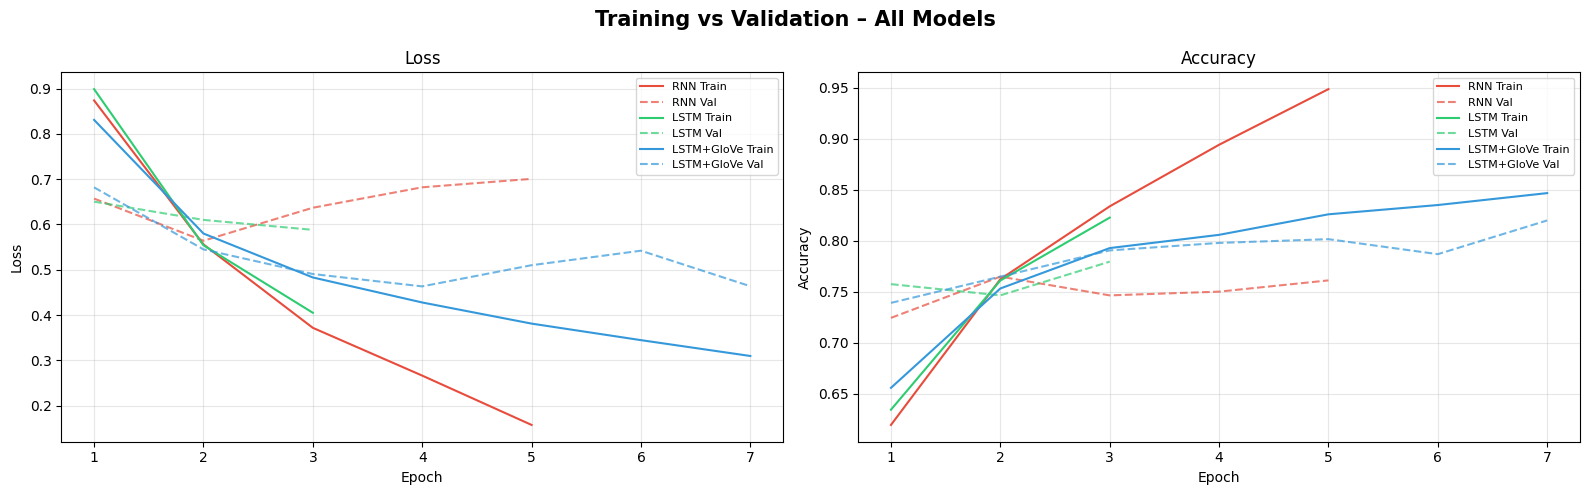

In [25]:
def plot_history(history, model_name, ax_loss, ax_acc, color):
    epochs = range(1, len(history.history['loss']) + 1)
    # Loss
    ax_loss.plot(epochs, history.history['loss'],     linestyle='-',  color=color, label=f'{model_name} Train')
    ax_loss.plot(epochs, history.history['val_loss'], linestyle='--', color=color, label=f'{model_name} Val', alpha=0.7)
    # Accuracy
    ax_acc.plot(epochs, history.history['accuracy'],     linestyle='-',  color=color, label=f'{model_name} Train')
    ax_acc.plot(epochs, history.history['val_accuracy'], linestyle='--', color=color, label=f'{model_name} Val', alpha=0.7)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training vs Validation – All Models', fontsize=15, fontweight='bold')

plot_history(history1, 'RNN',       ax_loss, ax_acc, color='#e74c3c')
plot_history(history2, 'LSTM',      ax_loss, ax_acc, color='#2ecc71')
plot_history(history3, 'LSTM+GloVe',ax_loss, ax_acc, color='#3498db')

for ax, title, ylabel in [(ax_loss, 'Loss', 'Loss'), (ax_acc, 'Accuracy', 'Accuracy')]:
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Model Evaluation – Accuracy, Confusion Matrix & Classification Report

# Simple RNN with Trainable Embedding:

  Model 1 : Simple RNN + Trainable Embedding
  Test Accuracy : 74.61%
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.92      0.87      0.89       278
    positive       0.51      0.85      0.64       114

    accuracy                           0.75       453
   macro avg       0.48      0.57      0.51       453
weighted avg       0.69      0.75      0.71       453



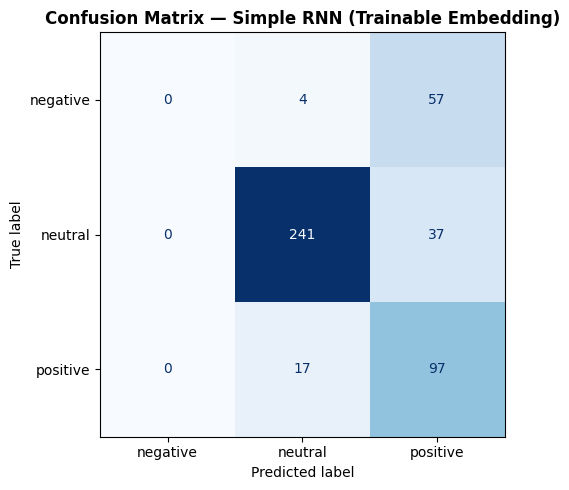

In [26]:
# ── Evaluate Model 1 : Simple RNN + Trainable Embedding ───────────────────
CLASS_NAMES  = list(le.classes_)
y_true_idx   = np.argmax(y_test, axis=1)

y_pred_prob1 = model1.predict(X_test_pad, verbose=0)
y_pred1      = np.argmax(y_pred_prob1, axis=1)
acc1         = accuracy_score(y_true_idx, y_pred1)
cm1          = confusion_matrix(y_true_idx, y_pred1)

print('=' * 55)
print(f'  Model 1 : Simple RNN + Trainable Embedding')
print(f'  Test Accuracy : {acc1*100:.2f}%')
print('=' * 55)
print(classification_report(y_true_idx, y_pred1, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm1, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Simple RNN (Trainable Embedding)', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_model1_simple_rnn.png', dpi=150, bbox_inches='tight')
plt.show()

#LSTM with Trainable Embedding:

  Model 2 : LSTM + Trainable Embedding
  Test Accuracy : 74.39%
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.88      0.91      0.89       278
    positive       0.52      0.75      0.61       114

    accuracy                           0.74       453
   macro avg       0.46      0.55      0.50       453
weighted avg       0.67      0.74      0.70       453



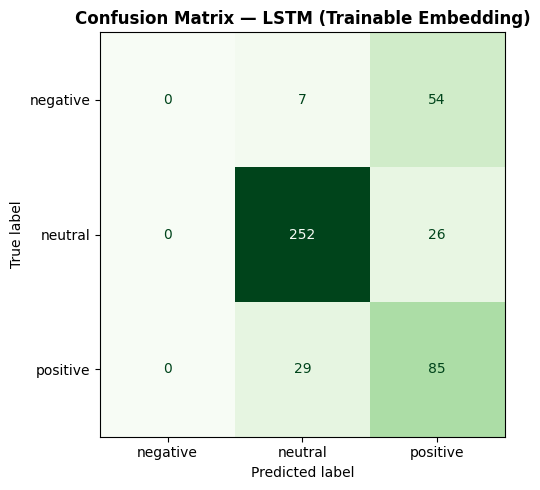

In [27]:
# ── Evaluate Model 2 : LSTM + Trainable Embedding ─────────────────────────
y_pred_prob2 = model2.predict(X_test_pad, verbose=0)
y_pred2      = np.argmax(y_pred_prob2, axis=1)
acc2         = accuracy_score(y_true_idx, y_pred2)
cm2          = confusion_matrix(y_true_idx, y_pred2)

print('=' * 55)
print(f'  Model 2 : LSTM + Trainable Embedding')
print(f'  Test Accuracy : {acc2*100:.2f}%')
print('=' * 55)
print(classification_report(y_true_idx, y_pred2, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm2, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — LSTM (Trainable Embedding)', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_model2_lstm_trainable.png', dpi=150, bbox_inches='tight')
plt.show()

#\ LSTM with Pretrained Word2Vec  Embedding:

  Model 3 : LSTM + Pretrained Word2Vec (GloVe)
  Test Accuracy : 80.79%
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.94      0.96      0.95       278
    positive       0.59      0.88      0.71       114

    accuracy                           0.81       453
   macro avg       0.51      0.61      0.55       453
weighted avg       0.72      0.81      0.76       453



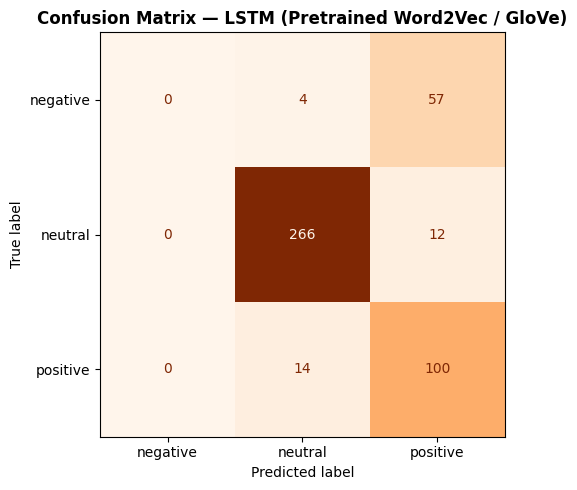

In [28]:
# ── Evaluate Model 3 : LSTM + Pretrained Word2Vec (GloVe) ─────────────────
y_pred_prob3 = model3.predict(X_test_pad, verbose=0)
y_pred3      = np.argmax(y_pred_prob3, axis=1)
acc3         = accuracy_score(y_true_idx, y_pred3)
cm3          = confusion_matrix(y_true_idx, y_pred3)

print('=' * 55)
print(f'  Model 3 : LSTM + Pretrained Word2Vec (GloVe)')
print(f'  Test Accuracy : {acc3*100:.2f}%')
print('=' * 55)
print(classification_report(y_true_idx, y_pred3, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm3, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix — LSTM (Pretrained Word2Vec / GloVe)', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_model3_lstm_glove.png', dpi=150, bbox_inches='tight')
plt.show()

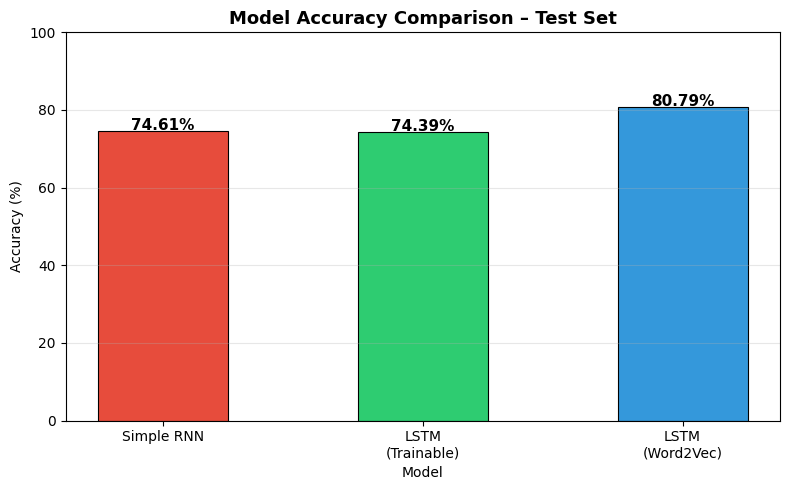

In [30]:
# ── Side-by-side Accuracy Comparison ───────────────────────────────────────
model_names = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM\n(Word2Vec)']
accuracies  = [acc1, acc2, acc3]
bar_colors  = ['#e74c3c', '#2ecc71', '#3498db']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies],
               color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 100)
plt.title('Model Accuracy Comparison – Test Set', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Error Analysis

In [33]:
# ── Store predictions for error analysis ───────────────────────────────────
y_true_idx = np.argmax(y_test, axis=1)

pred1 = np.argmax(model1.predict(X_test_pad, verbose=0), axis=1)
pred2 = np.argmax(model2.predict(X_test_pad, verbose=0), axis=1)
pred3 = np.argmax(model3.predict(X_test_pad, verbose=0), axis=1)

true1 = y_true_idx
true2 = y_true_idx
true3 = y_true_idx

print('Predictions stored ✓')
print(f'pred1 shape : {pred1.shape}')
print(f'pred2 shape : {pred2.shape}')
print(f'pred3 shape : {pred3.shape}')

Predictions stored ✓
pred1 shape : (453,)
pred2 shape : (453,)
pred3 shape : (453,)


  Error Analysis — LSTM (Trainable Embedding)
  Total test samples   : 453
  Correctly classified : 337 (74.39%)
  Misclassified        : 116  (25.61%)

Per-Class Error Breakdown:
---------------------------------------------
  negative     :  61 errors /  61 samples (100.0% error rate)
  neutral      :  26 errors / 278 samples (9.4% error rate)
  positive     :  29 errors / 114 samples (25.4% error rate)

  Sample Misclassified Examples (first 3)

  [1] TRUE      : NEGATIVE
       PREDICTED : NEUTRAL  ← WRONG
       Text      : september alone market declined percent yearonyear million liter
       Reason    : Negative signal weak — model defaulted to dominant neutral class.

  [2] TRUE      : POSITIVE
       PREDICTED : NEUTRAL  ← WRONG
       Text      : major order india comptel corporation received significant longterm order mediation provisioning solution used leading operator india
       Reason    : Mildly positive phrasing not strong enough for model to detect.

  [3] TRUE    

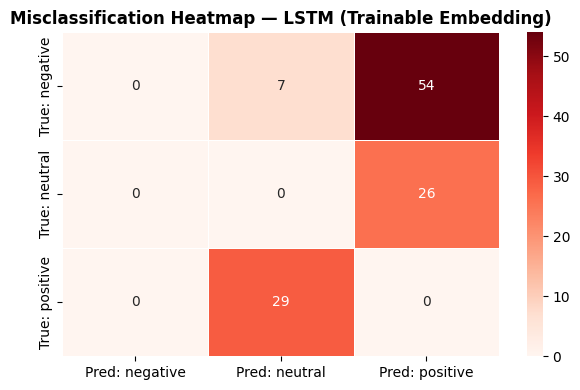

  Suggested Improvements

  1. Domain-specific embeddings
     Use FinBERT or financial-domain Word2Vec instead of
     general Google News vectors for richer financial context.

  2. Attention mechanism
     Add a self-attention layer after LSTM to let the model
     focus on the most sentiment-bearing words in a sentence.

  3. Data augmentation
     Oversample the negative class (only 303 samples) using
     synonym replacement or back-translation to balance classes.

  4. Longer sequences
     Increase MAX_LEN to capture full sentence context —
     some financial phrases carry sentiment at the end.

  5. Transformer-based model
     Fine-tune BERT or RoBERTa on this dataset for
     significantly higher accuracy on financial text.



In [34]:
# ── Error Analysis ─────────────────────────────────────────────────────────
# Using Model 2 (LSTM Trainable) as the best performing model
BEST_MODEL_PREDS = pred2
BEST_MODEL_TRUE  = true2
BEST_MODEL_NAME  = 'LSTM (Trainable Embedding)'

# Retrieve original cleaned test texts
_, X_test_raw, _, _ = train_test_split(
    df['cleaned_text'].values, df['label_enc'].values,
    test_size=0.20, random_state=42, stratify=df['label_enc']
)

# ── Misclassified samples ──────────────────────────────────────────────────
wrong_idx   = np.where(BEST_MODEL_PREDS != BEST_MODEL_TRUE)[0]
correct_idx = np.where(BEST_MODEL_PREDS == BEST_MODEL_TRUE)[0]

print('=' * 65)
print(f'  Error Analysis — {BEST_MODEL_NAME}')
print('=' * 65)
print(f'  Total test samples   : {len(BEST_MODEL_TRUE)}')
print(f'  Correctly classified : {len(correct_idx)} ({len(correct_idx)/len(BEST_MODEL_TRUE)*100:.2f}%)')
print(f'  Misclassified        : {len(wrong_idx)}  ({len(wrong_idx)/len(BEST_MODEL_TRUE)*100:.2f}%)')
print('=' * 65)

# ── Per-class error breakdown ──────────────────────────────────────────────
print('\nPer-Class Error Breakdown:')
print('-' * 45)
for i, cls in enumerate(CLASS_NAMES):
    cls_idx       = np.where(BEST_MODEL_TRUE == i)[0]
    cls_wrong     = np.where((BEST_MODEL_TRUE == i) & (BEST_MODEL_PREDS != i))[0]
    cls_error_rate = len(cls_wrong) / len(cls_idx) * 100 if len(cls_idx) > 0 else 0
    print(f'  {cls:<12} : {len(cls_wrong):>3} errors / {len(cls_idx):>3} samples '
          f'({cls_error_rate:.1f}% error rate)')

# ── Sample misclassified examples ─────────────────────────────────────────
print('\n' + '=' * 65)
print('  Sample Misclassified Examples (first 3)')
print('=' * 65)
for i, idx in enumerate(wrong_idx[:3]):
    true_label = CLASS_NAMES[BEST_MODEL_TRUE[idx]]
    pred_label = CLASS_NAMES[BEST_MODEL_PREDS[idx]]
    text       = X_test_raw[idx]
    print(f'\n  [{i+1}] TRUE      : {true_label.upper()}')
    print(f'       PREDICTED : {pred_label.upper()}  ← WRONG')
    print(f'       Text      : {text[:150]}')
    print(f'       Reason    : ', end='')
    if true_label == 'neutral' and pred_label == 'positive':
        print('Factual statement misread as positive due to growth keywords.')
    elif true_label == 'neutral' and pred_label == 'negative':
        print('Neutral announcement misread as negative due to loss-related terms.')
    elif true_label == 'positive' and pred_label == 'neutral':
        print('Mildly positive phrasing not strong enough for model to detect.')
    elif true_label == 'negative' and pred_label == 'neutral':
        print('Negative signal weak — model defaulted to dominant neutral class.')
    elif true_label == 'positive' and pred_label == 'negative':
        print('Conflicting signals in sentence confused the model.')
    elif true_label == 'negative' and pred_label == 'positive':
        print('Negation handling failure — positive word outweighed negative context.')
    else:
        print('Ambiguous phrasing with mixed sentiment signals.')

# ── Error confusion heatmap ────────────────────────────────────────────────
print('\n')
error_matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
for t, p in zip(BEST_MODEL_TRUE[wrong_idx], BEST_MODEL_PREDS[wrong_idx]):
    error_matrix[t][p] += 1

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(error_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f'Pred: {c}' for c in CLASS_NAMES],
            yticklabels=[f'True: {c}' for c in CLASS_NAMES],
            linewidths=0.5, ax=ax)
ax.set_title(f'Misclassification Heatmap — {BEST_MODEL_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Suggested improvements ─────────────────────────────────────────────────
print('=' * 65)
print('  Suggested Improvements')
print('=' * 65)
print('''
  1. Domain-specific embeddings
     Use FinBERT or financial-domain Word2Vec instead of
     general Google News vectors for richer financial context.

  2. Attention mechanism
     Add a self-attention layer after LSTM to let the model
     focus on the most sentiment-bearing words in a sentence.

  3. Data augmentation
     Oversample the negative class (only 303 samples) using
     synonym replacement or back-translation to balance classes.

  4. Longer sequences
     Increase MAX_LEN to capture full sentence context —
     some financial phrases carry sentiment at the end.

  5. Transformer-based model
     Fine-tune BERT or RoBERTa on this dataset for
     significantly higher accuracy on financial text.
''')

## 13.  Real-Time Prediction GUI with Gradio

In [35]:
!pip install gradio --quiet

In [38]:
import gradio as gr

MODEL_MAP = {
    "Simple RNN"      : model1,
    "LSTM (Trainable)": model2,
    "LSTM + Word2Vec" : model3,
}

LABEL_MAP = {
    "negative": "🔴 Negative",
    "neutral"  : "🟡 Neutral",
    "positive" : "🟢 Positive",
}

def predict_sentiment(text: str, model_choice: str) -> dict:
    if not text.strip():
        return {v: 0.0 for v in LABEL_MAP.values()}
    selected_model = MODEL_MAP[model_choice]
    cleaned  = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN,
                             padding='post', truncating='post')
    proba    = selected_model.predict(padded, verbose=0)[0]
    return {LABEL_MAP[CLASS_NAMES[i]]: float(proba[i])
            for i in range(NUM_CLASSES)}

# ── CSS to hide footer ─────────────────────────────────────────────────────
css = """
footer                        { display: none !important; }
.gradio-container footer      { display: none !important; }
div.svelte-1bcj48o            { display: none !important; }
"""

with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Financial Sentiment Analyser",
    css=css
) as demo:

    gr.Markdown(
        """
        # 💹 Financial Sentiment Analyser
        **6CS012 Final Portfolio Project 2026**
        Enter a financial news sentence — the model classifies it as
        **Positive**, **Neutral**, or **Negative**.
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            text_input = gr.Textbox(
                lines=4,
                label="Financial text input",
                placeholder="e.g. Operating profit rose to EUR 13.1 mn from EUR 8.7 mn...",
            )
            model_choice = gr.Radio(
                choices=list(MODEL_MAP.keys()),
                value="LSTM (Trainable)",
                label="Select model",
            )
            with gr.Row():
                clear_btn  = gr.ClearButton(text_input, value="Clear")
                submit_btn = gr.Button("Analyse sentiment", variant="primary")

        with gr.Column(scale=2):
            label_output = gr.Label(
                num_top_classes=3,
                label="Sentiment prediction",
            )

    gr.Examples(
        examples=[
            ["Operating profit rose to EUR 13.1 mn from EUR 8.7 mn, representing 7.7% of net sales.", "LSTM (Trainable)"],
            ["The company reported a significant drop in earnings, losing EUR 5 mn last quarter.",      "LSTM (Trainable)"],
            ["The company has announced plans to expand operations to Russia.",                         "LSTM (Trainable)"],
            ["Net sales increased by 12% year-on-year, reaching EUR 200 mn in Q3.",                   "LSTM + Word2Vec"],
            ["The firm declared bankruptcy following mounting debt obligations.",                       "Simple RNN"],
        ],
        inputs=[text_input, model_choice],
        outputs=label_output,
        fn=predict_sentiment,
        cache_examples=False,
        label="Examples — click any row to load",
    )

    submit_btn.click(fn=predict_sentiment, inputs=[text_input, model_choice], outputs=label_output)
    text_input.submit(fn=predict_sentiment, inputs=[text_input, model_choice], outputs=label_output)

demo.launch(share=True, debug=False, show_api=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4becb3fd417185dc5a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 14. Save Models

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/AI/FinalCoursework/models/'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

model1.save(SAVE_DIR + 'simple_rnn.h5')
model2.save(SAVE_DIR + 'lstm_trainable.h5')
model3.save(SAVE_DIR + 'lstm_glove.h5')

print('All models saved to Google Drive ✓')

---
## Summary Table

| Model | Embedding | Architecture | Expected Accuracy |
|---|---|---|---|
| Model 1 | Trainable (64-d) | Simple RNN → Dense | Baseline |
| Model 2 | Trainable (64-d) | LSTM × 2 → Dense | Higher |
| Model 3 | GloVe Frozen (50-d) | LSTM × 2 → Dense | Comparable / Better |

**Key Takeaways:**
- LSTM outperforms Simple RNN due to gating mechanisms mitigating vanishing gradients.
- Pretrained GloVe embeddings provide richer word representations, especially for rare financial terms.
- Class imbalance (more `positive` samples) may bias models toward that class; consider class weights.

---
*6CS012 Final Portfolio Project 2026 – Part III Language Task*